# Atelier Matplotlib 

## Structure du projet

In [ ]:
# %pip install ipykernel matplotlib pandas

  Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached pandas-3.0.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.0 MB)
Using cached pand

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


## Partie 1 – Graphique linéaire (Line Plot) 

### 1) Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille. 

#### D'abord, convertis la colonne date_heure en vrai type datetime et trie le dataframe chronologiquement (sinon la courbe part dans tous les sens si les lignes ne sont pas dans l'ordre) :

In [7]:
df["date_heure"] = pd.to_datetime(df["date_heure"])
df_sorted = df.sort_values("date_heure")

#### Puis traçons le graphique :

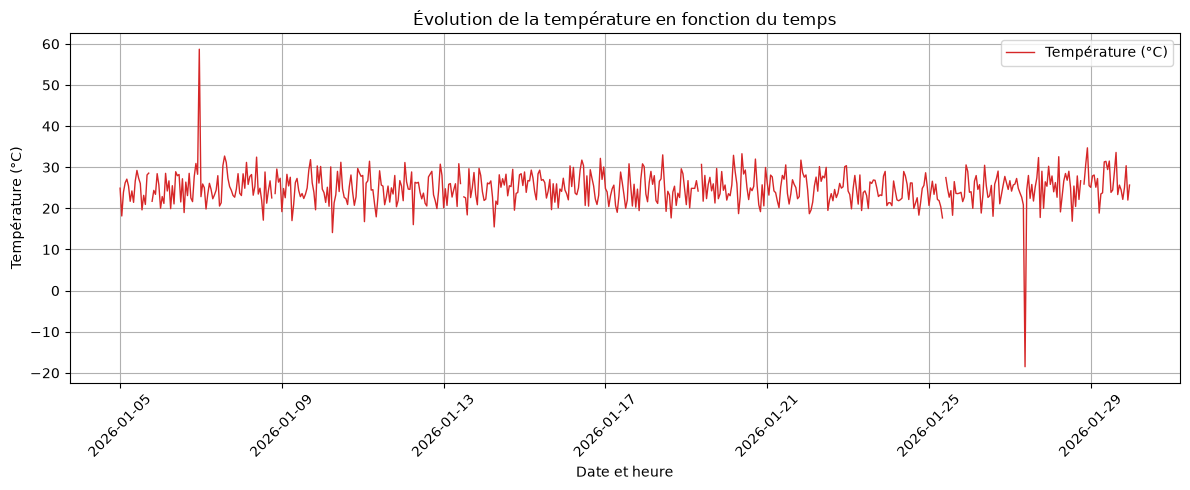

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(df_sorted["date_heure"], df_sorted["temperature"],
         color="tab:red", linewidth=1, label="Température (°C)")

plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date et heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2) Identifier visuellement les valeurs qui semblent anormales. 

#### En exécutant ce code , on voit deux pics qui sortent nettement de la plage habituelle (~18-30°C) :

#### une valeur proche de -18°C, autour du 26-27 janvier
#### une valeur proche de +59°C, autour du 6-7 janvier

#### Ces valeurs isolées et très éloignées du reste des points sont probablement des erreurs de capteur plutôt que de vraies variations physiques.

## Partie 2 – Diagramme en barres (Bar Chart) 

### 1) Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments 

#### On regroupe les données par bâtiment et on calcule la moyenne de la consommation :

In [9]:
consommation_batiment = df.groupby("batiment")["consommation"].mean()
consommation_batiment

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

### 2) Comparer graphiquement la consommation moyenne des bâtiments 

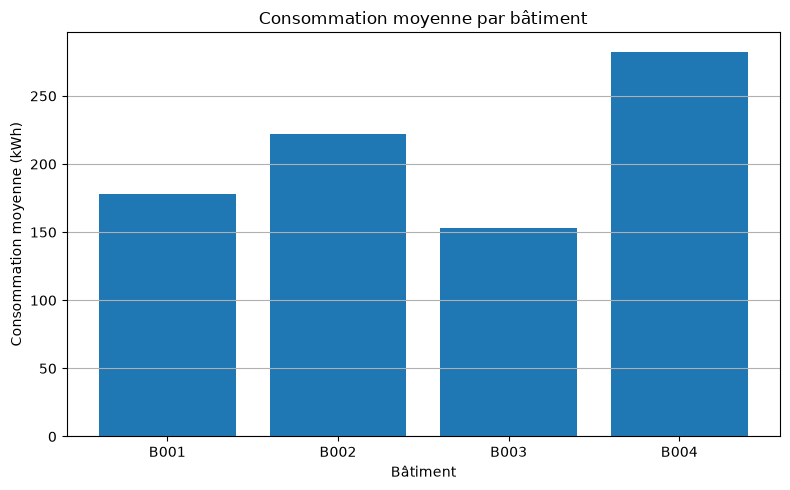

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(consommation_batiment.index, consommation_batiment.values, color="tab:blue")

plt.title("Consommation moyenne par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Consommation moyenne (kWh)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 3) Comparer la consommation moyenne des bâtiments avec un graphique horizontal 

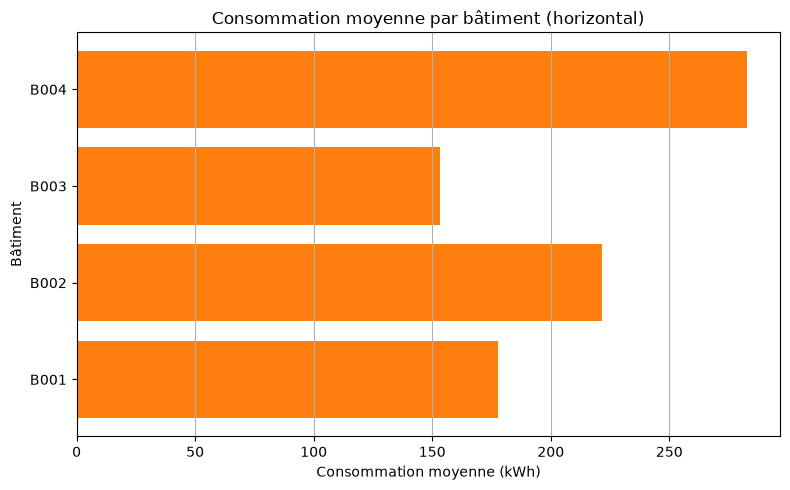

In [11]:
plt.figure(figsize=(8, 5))
plt.barh(consommation_batiment.index, consommation_batiment.values, color="tab:orange")

plt.title("Consommation moyenne par bâtiment (horizontal)")
plt.xlabel("Consommation moyenne (kWh)")
plt.ylabel("Bâtiment")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

### 4) Dans quels cas un graphique horizontal peut-il être plus lisible ? 

#### Quand les noms des catégories sont longs (ex: noms de bâtiments détaillés, intitulés de produits) — ils s'affichent horizontalement sans se chevaucher ni devoir être pivotés.
#### Quand il y a beaucoup de catégories — plus facile à lire en liste verticale qu'en barres serrées côte à côte.
#### Pour des classements (top 10, ranking) — l'œil lit naturellement de haut en bas, donc un ordre décroissant en barres horizontales se lit comme une liste triée. 